# Model training with Pure Asymmetric Likelihood

#### imports

In [410]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path
from scipy.stats import gaussian_kde
import time

import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import zuko

In [411]:
DATASET_PATH = Path("../../datasets/disasters_merged_all_feats.csv")
EVENT_GROUP = 'Storm'
RUN_PATH = Path(f"../../runs/flow_{EVENT_GROUP.lower()}.pt")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [412]:
# torch.manual_seed(42)
# np.random.seed(42)

## Data Preparation

In [413]:
df = pd.read_csv(DATASET_PATH)

### Group by event type

In [414]:
df['EVENT_GROUP'].value_counts()

EVENT_GROUP
Wind           152966
Hail            57980
Storm           55795
Flood           49691
Freeze          39347
Drought         20115
Snow            19792
Heat            14279
Heavy Rain      10488
Fog              4943
Wildfire         2505
Lightning        2261
Debris Flow      1047
Avalanche         203
Name: count, dtype: int64

In [415]:
event_group_dfs = {
    'Hail': df[df['EVENT_GROUP'] == 'Hail'].drop(columns=['EVENT_GROUP', 'WIND_SPEED']),
    'Wind': df[df['EVENT_GROUP'] == 'Wind'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Storm': df[df['EVENT_GROUP'] == 'Storm'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Flood': df[df['EVENT_GROUP'] == 'Flood'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Freeze': df[df['EVENT_GROUP'] == 'Freeze'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Drought': df[df['EVENT_GROUP'] == 'Drought'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Snow': df[df['EVENT_GROUP'] == 'Snow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heat': df[df['EVENT_GROUP'] == 'Heat'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heavy Rain': df[df['EVENT_GROUP'] == 'Heavy Rain'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Fog': df[df['EVENT_GROUP'] == 'Fog'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Wildfire': df[df['EVENT_GROUP'] == 'Wildfire'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Lightning': df[df['EVENT_GROUP'] == 'Lightning'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Debris Flow': df[df['EVENT_GROUP'] == 'Debris Flow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Avalanche': df[df['EVENT_GROUP'] == 'Avalanche'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
}

In [416]:
event_group_dfs['Hail'].head()

,DAMAGES,CASUALTIES,DURATION_HOURS,HAIL_SIZE,TIME_DAY_SIN,TIME_DAY_COS,TIME_YEAR_NORM,PRECIPITATION,TMIN,TMAX,...,SLOPE,COV_BARREN,COV_CULTIVATED,COV_VEGETATION,COV_FOREST,COV_WATER,COV_SNOW_ICE,COV_URBAN,RIVER_DISTANCE,SEA_DISTANCE
65,0.0,0,0.0,1.00,0.154204,0.988039,0.0,1404.65,11.66,22.69,...,1.89,0.000,0.716,0.146,0.136,0.002,0.0,0.000,256.4,415.3
72,0.0,0,0.0,0.88,0.353445,0.935455,0.0,1519.92,12.85,24.73,...,6.01,0.003,0.120,0.047,0.769,0.040,0.0,0.021,1082.0,170.3
74,0.0,0,0.0,1.00,0.353445,0.935455,0.0,1478.56,12.41,24.58,...,5.17,0.000,0.328,0.094,0.538,0.001,0.0,0.040,515.2,217.7
76,100.0,0,0.0,1.75,0.353445,0.935455,0.0,1589.20,12.37,24.92,...,7.35,0.000,0.049,0.020,0.930,0.001,0.0,0.000,925.4,142.4
82,0.0,0,0.0,1.00,0.353445,0.935455,0.0,1437.68,12.31,24.38,...,4.94,0.000,0.183,0.119,0.467,0.018,0.0,0.212,377.5,223.6


In [417]:
df = event_group_dfs[EVENT_GROUP]

### Data normalization

In [418]:
TARGET_COLS = ["DAMAGES"]

X_COLS = [
    'BEGIN_LAT', 'BEGIN_LON',
    'DURATION_HOURS', 'WIND_SPEED', # change with hail size for hail
    'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM',
    'PRECIPITATION', 'TMIN', 'TMAX',
    'ELEVATION', 'SLOPE',
    'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION',
    'COV_FOREST', 'COV_WATER', 'COV_SNOW_ICE', 'COV_URBAN',
    'RIVER_DISTANCE', 'SEA_DISTANCE'
]

In [419]:
X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

In [420]:
# targets log transformation
Y = np.log1p(Y)

In [421]:
# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

In [422]:
# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)


### Dataset split

In [423]:
# conversion to tensors and move to device
X_train = torch.tensor(X_train).to(device)
Y_train = torch.tensor(Y_train).to(device)

X_val = torch.tensor(X_val).to(device)
Y_val = torch.tensor(Y_val).to(device)

X_test = torch.tensor(X_test).to(device)
Y_test = torch.tensor(Y_test).to(device)


In [424]:
# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)

## Model - Pure Asymmetric Likelihood

### Model definition

In [425]:
EPOCHS = 20
BATCH_SIZE = 512
BASE_LR = 5e-3

# find warmup steps as function of epochs and dataset size
WARMUP_STEPS = int(0.1 * (len(train_ds) // BATCH_SIZE) * EPOCHS)

In [426]:
X_DIM = X_train.shape[1]
Y_DIM = Y_train.shape[1]

flow = zuko.flows.NSF(
    features=Y_DIM,
    context=X_DIM,
    transforms=12,
    hidden_features=[128, 128],
    bins=8
)

In [427]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader   = DataLoader(test_ds, batch_size=BATCH_SIZE)

In [428]:
flow = flow.to(device)

optimizer = torch.optim.Adam(flow.parameters(), lr=BASE_LR, weight_decay=1e-5)

warmup = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.1,
    total_iters=WARMUP_STEPS
)
cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS * len(train_loader) - WARMUP_STEPS,
    eta_min=1e-5
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup, cosine],
    milestones=[WARMUP_STEPS]
)

scaler = torch.amp.GradScaler(device=device)

ema = torch.optim.swa_utils.AveragedModel(
    flow,
    avg_fn=lambda averaged, model, num_averaged: 0.999 * averaged + 0.001 * model
)

In [429]:
print(f"NSF model created with {sum(p.numel() for p in flow.parameters())} parameters")

NSF model created with 267540 parameters


### Model training

In [430]:
class TrainingHistory:
    def __init__(self):
        self.train_losses = []
        self.val_losses = []
        self.lrs = []

In [431]:
history = TrainingHistory()
best_val_loss = np.inf
global_step = 0
# threshold = np.log1p(1e6)
threshold = torch.quantile(Y_train, 0.99)
lam = 5

for epoch in range(EPOCHS):
    t0 = time.time()
    flow.train()
    train_loss = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device.type):
            dist = flow(x)
            log_prob = dist.log_prob(y)
            extreme = (y > threshold).any(dim=1)
            weight = 1 + lam * extreme.float()
            loss = -(weight * log_prob).mean()


        scaler.scale(loss).backward()

        # gradient clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(flow.parameters(), 5.0)

        scaler.step(optimizer)
        scheduler.step()
        scaler.update()

        ema.update_parameters(flow)

        train_loss += loss.item()
        global_step += 1

    train_loss /= len(train_loader)

    # ---------- Validation ----------
    flow.eval()
    val_loss = 0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)
            loss = -flow(x).log_prob(y).mean()
            val_loss += loss.item()

    val_loss /= len(val_loader)

    history.train_losses.append(train_loss)
    history.val_losses.append(val_loss)
    history.lrs.append(optimizer.param_groups[0]["lr"])

    print(
        f"Epoch {epoch:03d} | "
        f"Time {time.time()-t0:.2f}s | "
        f"Train NLL {train_loss:.3f} | "
        f"Val NLL {val_loss:.3f} | "
        f"LR {optimizer.param_groups[0]['lr']:.2e}"
    )

    # Save EMA weights (better than raw model)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(ema.module.state_dict(), RUN_PATH)


Epoch 000 | Time 6.64s | Train NLL -0.230 | Val NLL -0.181 | LR 2.78e-03


c:\Users\matti\anaconda3\envs\ai311\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 001 | Time 10.03s | Train NLL -0.562 | Val NLL -1.475 | LR 5.00e-03
Epoch 002 | Time 7.01s | Train NLL -0.052 | Val NLL 0.253 | LR 4.96e-03
Epoch 003 | Time 6.83s | Train NLL -0.137 | Val NLL -1.092 | LR 4.85e-03
Epoch 004 | Time 6.69s | Train NLL -1.224 | Val NLL 0.423 | LR 4.66e-03
Epoch 005 | Time 6.89s | Train NLL -1.171 | Val NLL -2.380 | LR 4.41e-03
Epoch 006 | Time 6.93s | Train NLL -2.228 | Val NLL -0.210 | LR 4.10e-03
Epoch 007 | Time 6.71s | Train NLL -1.216 | Val NLL -1.014 | LR 3.75e-03
Epoch 008 | Time 6.90s | Train NLL -1.517 | Val NLL -2.097 | LR 3.35e-03
Epoch 009 | Time 6.98s | Train NLL -1.990 | Val NLL -1.801 | LR 2.93e-03
Epoch 010 | Time 6.83s | Train NLL -2.883 | Val NLL -3.195 | LR 2.50e-03
Epoch 011 | Time 7.10s | Train NLL -3.016 | Val NLL -3.646 | LR 2.07e-03
Epoch 012 | Time 7.62s | Train NLL -2.850 | Val NLL -3.766 | LR 1.65e-03
Epoch 013 | Time 7.09s | Train NLL -2.924 | Val NLL -3.625 | LR 1.25e-03
Epoch 014 | Time 7.34s | Train NLL -3.631 | Val NLL 

### Model Evaluation

In [432]:
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)

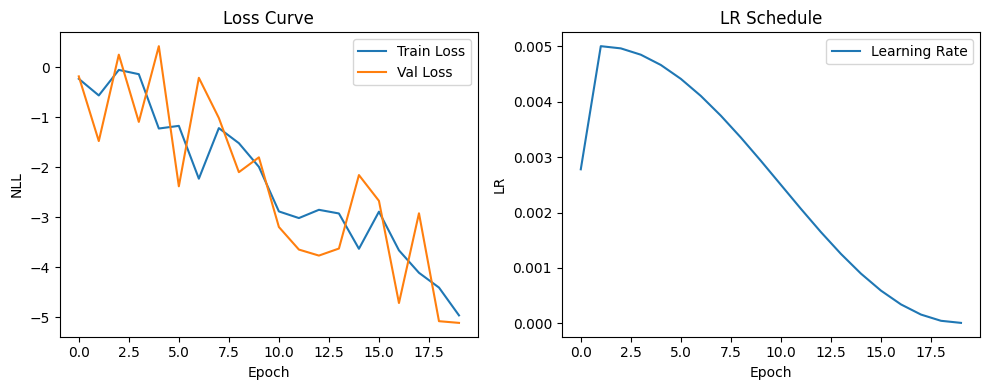

In [433]:
# plot training curves (loss and learning rate)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.train_losses, label='Train Loss')
plt.plot(history.val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('NLL')
plt.title('Loss Curve')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.lrs, label='Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.title('LR Schedule')
plt.legend()
plt.tight_layout()
plt.show()


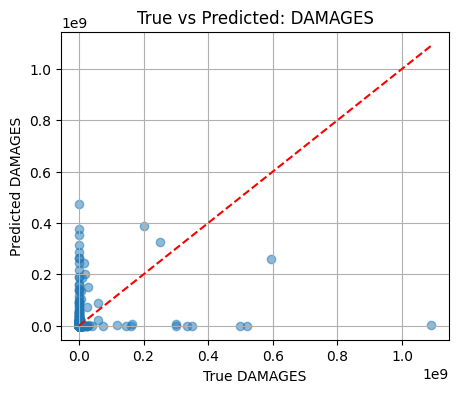

In [434]:
def run_inference_and_plot(flow, test_loader, y_scaler, target_cols):
    flow.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            dist = flow(x_batch)
            y_hat = dist.sample()
            # Ensure y_hat and y_batch are 2D
            if y_hat.ndim == 1:
                y_hat = y_hat.unsqueeze(1)
            if y_batch.ndim == 1:
                y_batch = y_batch.unsqueeze(1)
            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    if y_true.ndim == 1:
        y_true = y_true.reshape(-1, 1)
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)
    y_true = y_scaler.inverse_transform(y_true)
    y_pred = y_scaler.inverse_transform(y_pred)
    y_pred = np.expm1(np.clip(y_pred, -20, None))
    y_true = np.expm1(np.clip(y_true, -20, None))
    # Plot for the single target
    plt.figure(figsize=(5,4))
    plt.scatter(y_true[:, 0], y_pred[:, 0], alpha=0.5)
    plt.xlabel(f"True {target_cols[0]}")
    plt.ylabel(f"Predicted {target_cols[0]}")
    plt.title(f"True vs Predicted: {target_cols[0]}")
    plt.plot([y_true[:, 0].min(), y_true[:, 0].max()], [y_true[:, 0].min(), y_true[:, 0].max()], 'r--')
    plt.grid()
    plt.show()

run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS)

In [435]:
def compute_avg_true_pred_diff(flow, test_loader, y_scaler):
    flow.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            dist = flow(x_batch)
            y_hat = dist.sample().squeeze()
            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    if y_true.ndim == 1:
        y_true = y_true.reshape(-1, 1)
    if y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)
    y_true = y_scaler.inverse_transform(y_true)
    y_pred = y_scaler.inverse_transform(y_pred)
    y_pred = np.expm1(np.clip(y_pred, -20, None))
    y_true = np.expm1(np.clip(y_true, -20, None))
    avg_diff_damages = np.mean(np.abs(y_true[:, 0] - y_pred[:, 0]))
    print(f"Average absolute difference in {TARGET_COLS[0]}: {avg_diff_damages:.2f}")

compute_avg_true_pred_diff(flow, test_loader, y_scaler)

Average absolute difference in DAMAGES: 1608836.75


# Results

thresh: log(1e3), lambda: 4 - Average absolute difference in DAMAGES: 891516.19  
thresh: log(1e4), lambda: 4 - Average absolute difference in DAMAGES: 877352.75  
thresh: log(1e5), lambda: 4 - Average absolute difference in DAMAGES: 863744.31  
thresh: log(1e6), lambda: 4 - Average absolute difference in DAMAGES: 750928.31  
thresh: log(1e7), lambda: 4 - Average absolute difference in DAMAGES: 1171222.12  
thresh: log(5e7), lambda: 4 - Average absolute difference in DAMAGES: 848773.62  
thresh: log(1e8), lambda: 4 - Average absolute difference in DAMAGES: 741730.62

thresh: log(1e6), lambda: 3 - Average absolute difference in DAMAGES: 875002.88  
thresh: log(1e6), lambda: 5 - Average absolute difference in DAMAGES: 933404.81  

thresh: .95 q, lambda: 5 - Average absolute difference in DAMAGES: 2220892.00  
thresh: .99 q, lambda: 5 - Average absolute difference in DAMAGES: 1608836.75